<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/FEQ489_EstudodeCaso1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

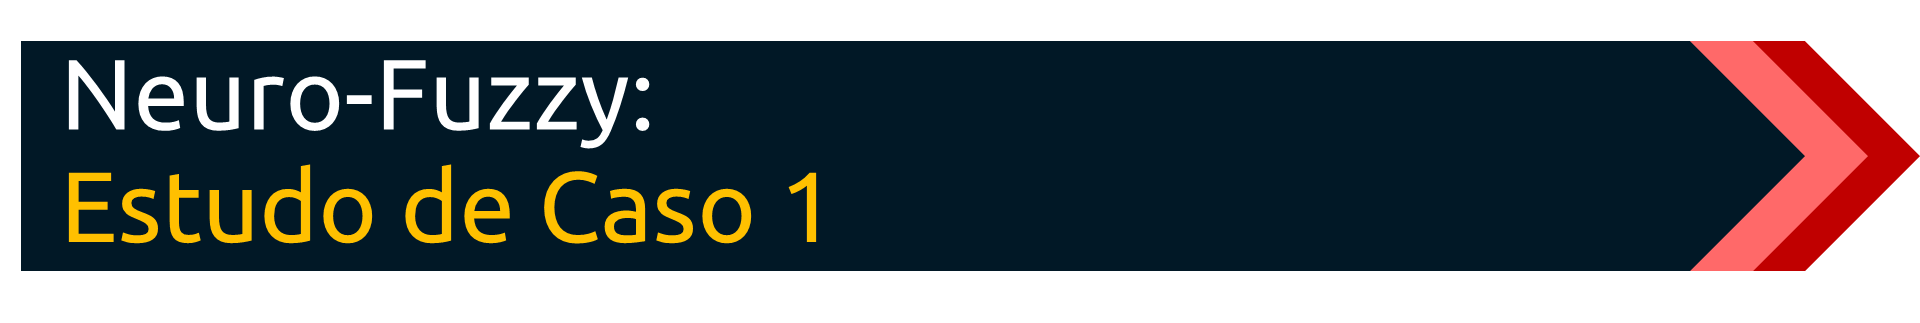

O principal objetivo deste estudo de caso é desenvolver e implementar um modelo de Machine Learning (Neuro-Fuzzy) capaz de prever a Classe de Qualidade final do produto de um reator químico com base em seus parâmetros de operação em tempo real.

O produto é classificado em três categorias:

1.   A (Qualidade Superior): Produto dentro das especificações de excelência.
2.   B (Qualidade Aceitável): Produto que atende aos requisitos mínimos, mas com margem de melhoria.
3. C (Qualidade Inferior/Rejeição): Produto fora das especificações, que requer reprocessamento ou descarte.

# **1. Importação dos Pacotes e Bibliotecas Necessários**

In [ ]:
# =================================================================
# 1. PRÉ-REQUISITOS, BIBLIOTECAS/PACOTES UTILIZADOS
# =================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow.keras as keras
from tensorflow.keras.utils import to_categorical
import joblib
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
from tensorflow.keras.optimizers import RMSprop


# **2. Parâmetros e Camadas do ANFIS**

In [ ]:
# ===============================================================
# 2. PARÂMETROS E CAMADAS DO ANFIS
# ===============================================================

class fis_parameters():
    def __init__(self, n_input, n_memb, n_output, batch_size, n_epochs, memb_func, optimizer, loss, adjust_premise):
        self.n_input = n_input
        self.n_memb = n_memb
        self.n_output = n_output  # Added n_output parameter
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.memb_func = memb_func
        self.optimizer = optimizer
        self.loss = loss
        self.adjust_premise = adjust_premise


class FuzzyLayer(keras.layers.Layer):
    def __init__(self, n_input, n_memb, memb_func='gaussian', **kwargs):
        super(FuzzyLayer, self).__init__(**kwargs)
        self.n_input = n_input
        self.n_memb = n_memb
        self.memb_func = memb_func

        # Inicializações adequadas (0±1)
        init_mean = tf.keras.initializers.RandomUniform(minval=-1.0, maxval=1.0)
        init_sigma = tf.keras.initializers.RandomUniform(minval=0.3, maxval=1.0)
        init_b = tf.keras.initializers.Constant(2.0)  # parâmetro b da gbellmf (fixo no início)

        self.means = self.add_weight(name='means', shape=(n_input, n_memb),
                                     initializer=init_mean, trainable=True)
        self.sigmas = self.add_weight(name='sigmas', shape=(n_input, n_memb),
                                      initializer=init_sigma, trainable=True)
        #self.b_params = self.add_weight(name='b_params', shape=(n_input, n_memb),
                                        #initializer=init_b, trainable=True)
        self.b_params = self.add_weight(name='b_params', shape=(n_input, n_memb),
                                        initializer=init_b, trainable=False)
        self.n_rules = int(np.power(self.n_memb, self.n_input))

    def call(self, inputs):
        eps = 1e-6
        sigmas_pos = tf.abs(self.sigmas) + eps
        b_pos = tf.abs(self.b_params) + eps

        expanded_inputs = tf.expand_dims(inputs, axis=2)  # (batch, n_input, 1)

        if self.memb_func == 'gaussian':
            x_minus_means = expanded_inputs - self.means
            normalized_distance = tf.square(x_minus_means / sigmas_pos)
            mu = tf.exp(-0.5 * normalized_distance)

        elif self.memb_func == 'triangular':
            abs_diff = tf.abs(expanded_inputs - self.means)
            mu = tf.maximum(0.0, 1.0 - abs_diff / sigmas_pos)

        elif self.memb_func == 'gbellmf':
            # Implementação da Generalized Bell
            a = sigmas_pos
            b = b_pos
            c = self.means
            mu = 1.0 / (1.0 + tf.pow(tf.abs((expanded_inputs - c) / (a + eps)), 2 * b))

        elif self.memb_func == 'sigmoid':
            # Implementação da Sigmoid: 1 / (1 + exp(-a * (x - c)))
            # 'a' é o slope, 'c' é o centro
            a = self.sigmas # O slope (a) pode ser negativo para inverter a curva
            c = self.means
            exponent = -a * (expanded_inputs - c)
            mu = 1.0 / (1.0 + tf.exp(exponent))

        else:
            raise ValueError("Função de pertinância inválida. Use 'gaussian', 'triangular', 'gbellmf' ou 'sigmoid'.")

        # Combinação fuzzy (produto das pertinêAncias)
        indices = []
        for i in range(self.n_input):
            repeat = int(np.power(self.n_memb, self.n_input - 1 - i))
            tile = int(np.power(self.n_memb, i))
            index_i = np.repeat(np.arange(self.n_memb), repeat)
            index_i = np.tile(index_i, tile)
            indices.append(index_i)

        mu_rules = []
        for i in range(self.n_rules):
            rule_mus = []
            for j in range(self.n_input):
                rule_mus.append(mu[:, j, indices[j][i]])
            mu_rule = tf.reduce_prod(tf.stack(rule_mus, axis=1), axis=1)
            mu_rules.append(mu_rule)

        mu_rules = tf.stack(mu_rules, axis=1)
        return mu_rules


class RuleLayer(keras.layers.Layer):
    def __init__(self, n_input, n_memb, n_output, **kwargs): # Added n_output
        super(RuleLayer, self).__init__(**kwargs)
        self.n_input = n_input
        self.n_memb = n_memb
        self.n_rules = int(np.power(self.n_memb, self.n_input))
        self.n_output = n_output # Store n_output

        # Consequents now need to produce n_output values for each rule
        # Shape: (n_rules, n_output, n_input + 1)
        self.consequents = self.add_weight(name='consequents',
                                           shape=(self.n_rules, self.n_output, self.n_input + 1), # Shape changed
                                           initializer='zeros',
                                           trainable=True)

    def call(self, inputs):
        mu_rules = inputs[0] # (batch, n_rules)
        X = inputs[1]        # (batch, n_input)

        sum_mu = tf.reduce_sum(mu_rules, axis=1, keepdims=True)
        mu_rules_norm = mu_rules / (sum_mu + tf.keras.backend.epsilon()) # (batch, n_rules)

        ones = tf.ones((tf.shape(X)[0], 1), dtype=X.dtype)
        X_extended = tf.concat([ones, X], axis=1) # (batch, n_input + 1)

        # Calculate f_k_raw for each rule, for each output class
        # f_k_raw should have shape (batch, n_rules, n_output)
        f_k_raw = tf.einsum('bi,rci->brc', X_extended, self.consequents) # (batch, n_rules, n_output)

        # Apply normalized firing strengths (mu_rules_norm)
        mu_rules_norm_expanded = tf.expand_dims(mu_rules_norm, axis=2) # (batch, n_rules, 1)

        # Element-wise multiplication, then sum over rules dimension
        y_pred_logits = tf.reduce_sum(mu_rules_norm_expanded * f_k_raw, axis=1) # (batch, n_output)

        return y_pred_logits # This output is now (batch_size, n_output)


class ANFIS(keras.Model):
    def __init__(self, param, input_cols=None, **kwargs):
        super(ANFIS, self).__init__(**kwargs)
        self.param = param
        self.input_cols = input_cols
        self.fuzzy_layer = FuzzyLayer(param.n_input, param.n_memb, memb_func=param.memb_func)
        self.rule_layer = RuleLayer(param.n_input, param.n_memb, param.n_output) # Pass n_output

    def call(self, inputs):
        mu_rules = self.fuzzy_layer(inputs)
        y_pred_logits = self.rule_layer([mu_rules, inputs])
        # For classification with categorical_crossentropy, return probabilities via softmax
        return tf.nn.softmax(y_pred_logits)

    # === Plot das funções de pertinêAncia ===
    def plotmfs(self): # Removed show_initial_weights
        n_input = self.param.n_input
        n_memb = self.param.n_memb
        #x_plot = np.linspace(0, 1, 200)
        x_plot = np.linspace(-3, 3, 200)

        # Extrai os pesos treinados
        means = self.fuzzy_layer.means.numpy()
        sigmas_raw = self.fuzzy_layer.sigmas.numpy() # Sigmas brutos (com sinal)
        b_vals = self.fuzzy_layer.b_params.numpy()

        plt.figure(figsize=(5 * n_input, 4))
        for i in range(n_input):
            plt.subplot(1, n_input, i + 1)
            for j in range(n_memb):
                # Ensure positive sigma for gaussian/triangular for calculations
                sig_val = np.abs(sigmas_raw[i, j]) + 1e-6 # Add epsilon for stability
                b_val = np.abs(b_vals[i, j]) + 1e-6

                if self.param.memb_func == 'gaussian':
                    mf = np.exp(-0.5 * ((x_plot - means[i, j]) / sig_val)**2)
                elif self.param.memb_func == 'triangular':
                    abs_diff = np.abs(x_plot - means[i, j])
                    mf = np.maximum(0.0, 1.0 - abs_diff / sig_val)
                elif self.param.memb_func == 'gbellmf':
                    a = sig_val
                    b = b_val
                    c = means[i, j]
                    mf = 1 / (1 + np.abs((x_plot - c) / a)**(2*b))
                elif self.param.memb_func == 'sigmoid':
                    a = sigmas_raw[i, j] # slope, can be negative
                    c = means[i, j] # center
                    mf = 1.0 / (1.0 + np.exp(-a * (x_plot - c)))

                plt.plot(x_plot, mf, label=f'MF{j+1}')

            # Garante que o título use input_cols se estiver disponível
            title = self.input_cols[i] if self.input_cols and len(self.input_cols) > i else f'Entrada {i+1}'

            plt.title(f'Funções de Pertinência - {title}')
            #plt.xlabel('Valor Normalizado (MinMax)')
            plt.xlabel('Valor Normalizado (Z-Score)')
            plt.ylabel('Grau de Pertinência')
            plt.legend()
            plt.grid(True)
        plt.tight_layout()
        plt.show()

    # === Exporta regras fuzzy em formato textual (.txt) ===
    def export_rules_txt(self, filename='regras_anfis.txt', class_labels=None): # Added class_labels
        consequents = self.rule_layer.consequents.numpy() # (n_rules, n_output, n_input + 1)
        # means = self.fuzzy_layer.means.numpy() # Not directly used in consequent string
        n_rules = consequents.shape[0]
        n_input = self.param.n_input
        n_memb = self.param.n_memb
        n_output = self.param.n_output # Use n_output

        # Check if class_labels are provided
        if class_labels is None:
            class_labels = [f"Class_{k+1}" for k in range(n_output)]

        # índice combinatório das regras
        indices = []
        for i in range(n_input):
            repeat = int(np.power(n_memb, n_input - 1 - i))
            tile = int(np.power(n_memb, i))
            index_i = np.repeat(np.arange(n_memb), repeat)
            index_i = np.tile(index_i, tile)
            indices.append(index_i)

        with open(filename, 'w', encoding='utf-8') as f:
            f.write("=== Regras Fuzzy ANFIS ===\n\n")
            for r in range(n_rules):
                conditions = []
                for j in range(n_input):
                    var_name = self.input_cols[j] if self.input_cols else f"X{j+1}"
                    mf_name = f"MF{indices[j][r]+1}"
                    conditions.append(f"{var_name} \u00c9 {mf_name}")
                antecedent = " E ".join(conditions)

                # Now handle multiple consequents for each output class
                consequent_parts = []
                for c_idx in range(n_output):
                    coef = consequents[r, c_idx, :] # Get coefficients for this rule and this output class
                    consequent_str_c = f"{{class_labels[c_idx]}} = {coef[0]:.4f}" # Intercept term
                    for j in range(1, len(coef)):
                        var_name = self.input_cols[j-1] if self.input_cols else f"X{j}"
                        consequent_str_c += f" + ({coef[j]:.4f})*{{var_name}}"
                    consequent_parts.append(consequent_str_c)

                # Join consequents for different classes
                full_consequent = " E ".join(consequent_parts)
                f.write(f"Regra {r+1}: SE {antecedent} ENT\u00c3O {full_consequent}\n")
        print(f"\n\u2705 Regras exportadas com sucesso para '{filename}'\n")

# **3. Leitura dos Dados**

In [ ]:
# ====================================================================
# 3. LEITURA BANCO DE DADOS
# ====================================================================

if __name__ == '__main__':
    # Leitura dos dados do CSV
    try:
        # Alimentação do dataset
        df = pd.read_csv('reator.csv')

        target_name = df.columns[-1]
        print(f"Coluna de Saída (Target): {target_name}")

    except FileNotFoundError:
        print(
            "Erro: O arquivo '.csv' não foi encontrado. Certifique-se de que ele está no mesmo diretório do script Python.")
        exit()
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        exit()

    # Definindo entradas (X) e saídas (Y)
    X_full = df.iloc[:, :-1]
    Y = df.iloc[:, -1].values.astype(str)

Coluna de Saída (Target): Classe_Qualidade


In [ ]:
df.head()

,Temperatura_Reator (C),Pressão_Entrada (bar),Vazão_Catalisador (L/min),Tempo_Residência (min),Concentração_Impureza (%),Classe_Qualidade
0,153.50,3.95,0.85,30.93,0.06,A
1,148.85,4.41,0.89,29.68,0.42,B
2,152.48,3.33,0.95,32.19,0.08,A
3,152.35,3.97,0.86,32.21,0.08,A
4,148.69,4.23,0.86,28.61,0.50,B


# **4. Seleção dos Atributos**

In [ ]:
# ---------------------------------------------------------------
# 4. SELEÇÃO DE ATRIBUTOS
# ---------------------------------------------------------------

MODO_SELECAO = 'AUTOMATICO'
K_ATRIBUTOS = 3

X = X_full.values
input_names = X_full.columns.tolist()

if MODO_SELECAO == 'AUTOMATICO':
        le_temp = LabelEncoder()
        Y_encoded_temp = le_temp.fit_transform(Y)
        selector = SelectKBest(score_func=f_classif, k=K_ATRIBUTOS)
        selector.fit(X_full.values, Y_encoded_temp)
        selected_features_mask = selector.get_support()
        input_names_used = X_full.columns[selected_features_mask].tolist()
        X = X_full.values[:, selected_features_mask]

        print(f"\nMODO AUTOMÁTICO (K={K_ATRIBUTOS}):")
        print(f"Os {K_ATRIBUTOS} melhores atributos selecionados são: {input_names_used}")
else:
        # Se não for automático, usa todos
        input_names_used = input_names
        X = X_full.values
        print(f"\nMODO MANUAL: Utilizando todos os {len(input_names_used)} atributos.")

N_INPUT = X.shape[1]

if N_INPUT == 0:
    print("Erro: Nenhum atributo selecionado. Verifique o CSV e a configuração.")
    exit()


MODO AUTOMÁTICO (K=3):
Os 3 melhores atributos selecionados são: ['Temperatura_Reator (C)', 'Tempo_Residência (min)', 'Concentração_Impureza (%)']


# **5. Pré-Processamento para Classificador Multiclasse**

In [ ]:
# ---------------------------------------------------------------
# 5. PRÉ-PROCESSAMENTO PARA CLASSIFICAÇÃO MULTICLASSE
# ---------------------------------------------------------------

label_encoder = LabelEncoder()
Y_encoded = label_encoder.fit_transform(Y)
class_labels = label_encoder.classes_.tolist()
N_CLASSES = len(class_labels)
Y_one_hot = to_categorical(Y_encoded)

print(f"Tipo de problema: Classificação Multiclasse ({N_CLASSES} classes)")
print(f"Rótulos das Classes: {class_labels}")

# Dividir os dados: Treino (70%), Validação (15%), Teste (15%)
X_train, x_temp, Y_train_oh, y_temp_oh = train_test_split(X, Y_one_hot, test_size=0.30, random_state=42)
X_test, X_val, Y_test_oh, Y_val_oh = train_test_split(x_temp, y_temp_oh, test_size=0.5, random_state=42)

# Normalizar entradas (X) entre 0 e 1 (obrigatório para ANFIS)
scaler_x = MinMaxScaler()
X_train = scaler_x.fit_transform(X_train)
X_val = scaler_x.transform(X_val)
X_test = scaler_x.transform(X_test)

Tipo de problema: Classificação Multiclasse (3 classes)
Rótulos das Classes: ['A', 'B', 'C']


# **6. Bloco Principal de Execução**

In [ ]:
# ---------------------------------------------------------------
# 6. BLOCO PRICIPAL DE EXECUÇÃO (Configuração ANFIS)
# ---------------------------------------------------------------
param = fis_parameters(
n_input=N_INPUT,
n_memb=2,  # no. de funções de pertinência por input
n_output=N_CLASSES,
batch_size=8,
memb_func='sigmoid', #gaussian; triangular, gbellmf, sigmoid
optimizer='adam',
loss='categorical_crossentropy',
n_epochs=75,
adjust_premise=True
    )

# Criando o sistema neuro-fuzzy
fis = ANFIS(param=param,
                input_cols=input_names_used,
                name='myanfis_class')

# Definição da taxa de aprendizado (Learning Rate)
LEARNING_RATE = 1e-3
otimizer_anfis = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Parar o treinamento se a 'val_loss' não melhorar após 6 épocas.
early_stopping_cb = EarlyStopping(
    monitor='val_loss',
    #monitor='val_f1_score',
    patience=15,
    restore_best_weights=True,
    verbose=1,
    #mode='max' # Added mode='max'
)

# Calcular pesos das classes para lidar com desbalanceamento
Y_train_labels_for_weights = np.argmax(Y_train_oh, axis=1)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y_train_labels_for_weights),
    y=Y_train_labels_for_weights
)
class_weight_dict = dict(enumerate(class_weights))

# Compilando o modelo (call compile on fis object directly)
fis.compile(optimizer=otimizer_anfis,
                      loss=param.loss,
                      metrics=['accuracy'])

# Iniciando o treinamento (call fit on fis object directly)
print("\n--- Iniciando Treinamento para o Classificador ANFIS ---")
history_anfis = fis.fit(X_train, Y_train_oh,
                            epochs=param.n_epochs,
                            batch_size=param.batch_size,
                            validation_data=(X_val, Y_val_oh),
                            callbacks=[early_stopping_cb],
                            class_weight=class_weight_dict,
                            verbose=1) # Changed from fis.model.fit, removed input_names_used

# --- GERAÇÃO DA BASE DE REGRAS APÓS O TREINAMENTO ---
fis.export_rules_txt(filename=f'base_de_regras_anfis_{param.memb_func}.txt',
                            class_labels=class_labels) # Removed input_names argument


--- Iniciando Treinamento para o Classificador ANFIS ---
Epoch 1/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.4314 - loss: 1.0957 - val_accuracy: 0.6000 - val_loss: 1.0789
Epoch 2/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5900 - loss: 1.0738 - val_accuracy: 0.6000 - val_loss: 1.0607
Epoch 3/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6153 - loss: 1.0513 - val_accuracy: 0.6000 - val_loss: 1.0444
Epoch 4/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6529 - loss: 1.0399 - val_accuracy: 0.6267 - val_loss: 1.0294
Epoch 5/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6375 - loss: 1.0342 - val_accuracy: 0.6267 - val_loss: 1.0146
Epoch 6/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6427 - loss: 1.0280 - val_accuracy: 0.6267 - val_loss: 0.9997
Epoch 7/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6584 - loss: 0.9962 - val_accuracy: 0.6267 - val_loss: 0.9846
Epoch 8/75
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accurac

# **7. Avaliação dos Resultados**

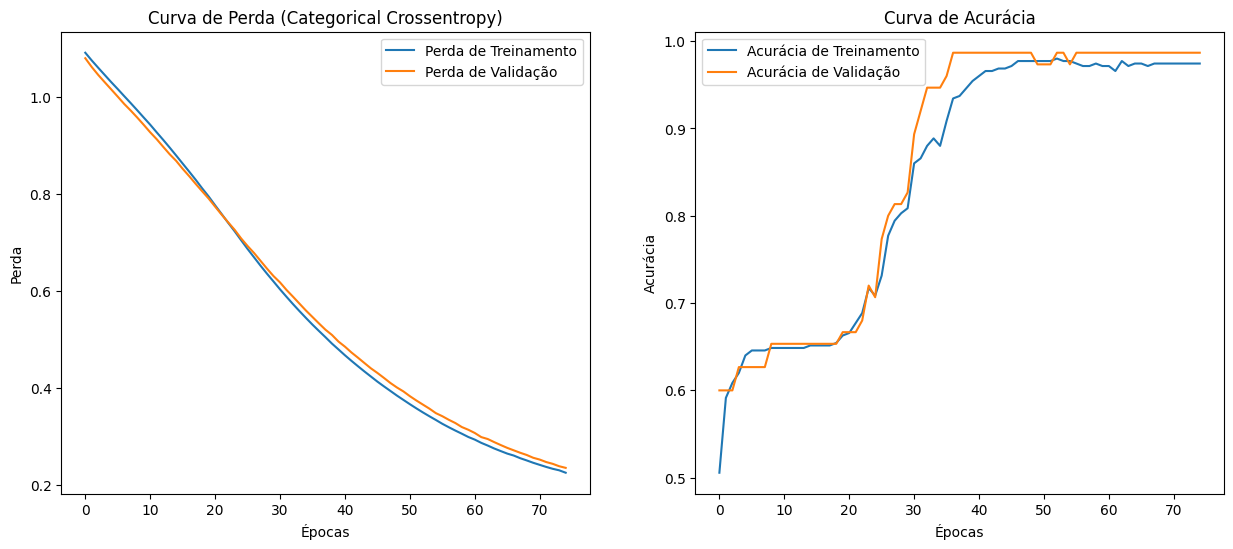

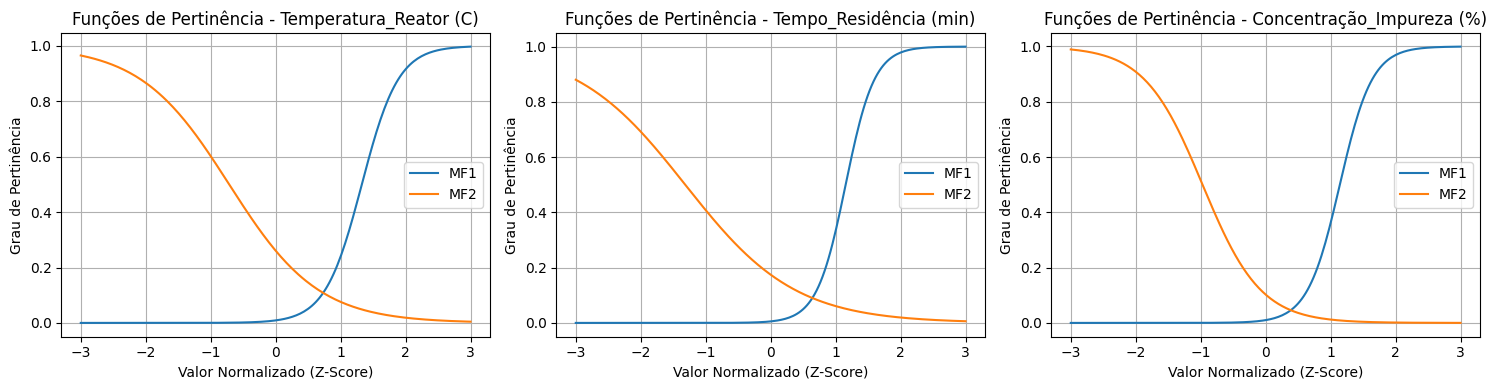


--- Métricas de Treinamento e Teste ---
Acurácia de treinamento final: 0.9743
Acurácia de validação final: 0.9867
Acurácia de teste: 0.9867

MATRIZ DE CONFUSÃO
        Previsto A  Previsto B  Previsto C
Real A          30           0           0
Real B           0          27           0
Real C           0           1          17

RELATÓRIO DETALHADO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        30
           B       0.96      1.00      0.98        27
           C       1.00      0.94      0.97        18

    accuracy                           0.99        75
   macro avg       0.99      0.98      0.98        75
weighted avg       0.99      0.99      0.99        75


Modelo Keras (anfis_classificador.h5) salvo com sucesso.
Scaler (scaler_x.pkl) salvo com sucesso.
Label Encoder (label_encoder.pkl) salvo com sucesso.


In [ ]:
# =================================================================
# 7. AVALIAÇÃO DOS RESULTADOS
# =================================================================

# 7.1. Plotagem (Adicionando o código de plotagem para quem quiser ver as curvas)
fig, axs = plt.subplots(1, 2, figsize=(15, 6))

axs[0].plot(history_anfis.history['loss'], label='Perda de Treinamento')
axs[0].plot(history_anfis.history['val_loss'], label='Perda de Validação')
axs[0].set_title('Curva de Perda (Categorical Crossentropy)')
axs[0].set_xlabel('Épocas')
axs[0].set_ylabel('Perda')
axs[0].legend()

axs[1].plot(history_anfis.history['accuracy'], label='Acurácia de Treinamento')
axs[1].plot(history_anfis.history['val_accuracy'], label='Acurácia de Validação')
axs[1].set_title('Curva de Acurácia')
axs[1].set_xlabel('Épocas')
axs[1].set_ylabel('Acurácia')
axs[1].legend()

plt.show() # Descomente para exibir os gráficos

# Funções de pertinência após o treinamento (necessita da implementação 'fis')
fis.plotmfs() # Removed show_initial_weights=True

# --------------------------------------------------------------------
# 7.2. CÁLCULO DAS MÉTRICAS (Matriz de Confusão e Relatório)
# --------------------------------------------------------------------

# Converte o Y_test_oh (Real) de One-Hot para Label Numérico (ex: 0, 1, 2)
Y_test_labels = np.argmax(Y_test_oh, axis=1)

# Faz a previsão no conjunto de Teste (Y_pred_oh é a saída One-Hot do modelo Keras/ANFIS)
Y_pred_oh = fis.predict(X_test, verbose=0) # Changed from fis.model.predict

# Converte o Y_pred (Previsto) de One-Hot para Label Numérico (ex: 0, 1, 2)
Y_pred_labels = np.argmax(Y_pred_oh, axis=1)

# Acurácia de Teste
Acc_test_anfis = accuracy_score(Y_test_labels, Y_pred_labels)
train_acc = history_anfis.history['accuracy'][-1]
val_acc = history_anfis.history['val_accuracy'][-1]


print("\n--- Métricas de Treinamento e Teste ---")
print(f"Acurácia de treinamento final: {train_acc:.4f}")
print(f"Acurácia de validação final: {val_acc:.4f}")
print(f"Acurácia de teste: {Acc_test_anfis:.4f}")


# MATRIZ DE CONFUSÃO
print("\n" + "="*50)
print("MATRIZ DE CONFUSÃO")
print("="*50)

# Fix: Pass all possible class labels to ensure the confusion matrix has the correct dimensions
conf_mat = confusion_matrix(Y_test_labels, Y_pred_labels, labels=np.arange(N_CLASSES))

# Cria um DataFrame para melhor visualização da Matriz
conf_mat_df = pd.DataFrame(conf_mat,
                           index=[f'Real {c}' for c in class_labels],
                           columns=[f'Previsto {c}' for c in class_labels])

print(conf_mat_df)

# RELATÓRIO DE CLASSIFICAÇÃO
print("\n" + "="*50)
print("RELATÓRIO DETALHADO DE CLASSIFICAÇÃO")
print("="*50)

# Mapeia os labels (0, 1, 2) de volta para as classes originais ('A', 'B', 'C')
report = classification_report(Y_test_labels, Y_pred_labels, target_names=class_labels, labels=np.arange(N_CLASSES), zero_division=0)
print(report)


# ====================================================================
# SALVAMENTO DO MODELO E PRÉ-PROCESSADORES
# ====================================================================

fis.save('anfis_classificador.h5') # Changed from fis.model.save
print("\nModelo Keras (anfis_classificador.h5) salvo com sucesso.")
joblib.dump(scaler_x, 'scaler_x.pkl')
print("Scaler (scaler_x.pkl) salvo com sucesso.")
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Label Encoder (label_encoder.pkl) salvo com sucesso.")
# ====================================================================

# **8. Avaliação com nova amostra**

In [ ]:
# ==============================================================================
# 8. TESTE COM NOVA AMOSTRA
# ==============================================================================

# N_INPUT é 3, pois você usou 3 features (K_ATRIBUTOS=3)

NOVA_AMOSTRA_BRUTA = np.array([[153, 25, 0.62]])  # Formato (1, N_INPUT)

print("\n--- Teste de Classificação de Nova Amostra ---")
print(f"Nova Amostra Bruta (Input): {NOVA_AMOSTRA_BRUTA[0]}")

# 1. Pré-processar/Normalizar a nova amostra
nova_amostra_escalada = scaler_x.transform(NOVA_AMOSTRA_BRUTA)

# 2. Fazer a Previsão (Predição)
previsao_one_hot = fis.predict(nova_amostra_escalada, verbose=0)

# 3. Decodificar o resultado
indice_classe_predita = np.argmax(previsao_one_hot, axis=1)[0]

# O inverse_transform requer um array de índices
classe_predita = label_encoder.inverse_transform([indice_classe_predita])[0]
probabilidade_max = previsao_one_hot[0, indice_classe_predita]

# 4. Imprimir o resultado
print("-" * 50)
print(f"Probabilidades One-Hot: {np.around(previsao_one_hot[0],3)}")
print(f"Classe Predita: {classe_predita}")
print(f"Confiança: {probabilidade_max:.4f}")
print("-" * 50)


--- Teste de Classificação de Nova Amostra ---
Nova Amostra Bruta (Input): [153.    25.     0.62]
--------------------------------------------------
Probabilidades One-Hot: [0.113 0.682 0.205]
Classe Predita: B
Confiança: 0.6818
--------------------------------------------------
